In [ ]:
!pip install -q datasets transformers accelerate scikit-learn matplotlib

In [ ]:
from datasets import load_dataset
from collections import Counter
import pandas as pd

In [ ]:
# Loading the small labelled Cyber Threat Intelligence V2 dataset and printing it
dataset = load_dataset("Olec/cyber-threat-intelligence_v2")
print(dataset)

C:\Users\Sanjana\anaconda3\envs\cti\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sanjana\.cache\huggingface\hub\datasets--Olec--cyber-threat-intelligence_v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 72/72 [00:00<00:00, 3356.75 examples/s]


In [ ]:
# prinitng the total number of training, validation and test samples
print("Training samples :", len(dataset["train"]))
print("Validation samples:", len(dataset["validation"]))
print("Test samples      :", len(dataset["test"]))

Training samples : 332
Validation samples: 76
Test samples      : 72


In [ ]:
# prinitng each field and its value for the first sample from the training dataset
sample = dataset["train"][0]
for key, value in sample.items():
    print(f"{key}:")
    print(value)
    print("-"*60)

id:
249
------------------------------------------------------------
text:
A cybersquatting domain save-russia[.]today is launching DoS attacks on Ukrainian news sites.
------------------------------------------------------------
entities:
[{'end_offset': 16, 'id': 44656, 'label': 'attack-pattern', 'start_offset': 2}, {'end_offset': 43, 'id': 44657, 'label': 'url', 'start_offset': 24}, {'end_offset': 68, 'id': 44658, 'label': 'attack-pattern', 'start_offset': 57}, {'end_offset': 92, 'id': 44659, 'label': 'identity', 'start_offset': 72}]
------------------------------------------------------------
relations:
[{'from_id': 44658, 'id': 9, 'to_id': 44659, 'type': 'targets'}, {'from_id': 44656, 'id': 114, 'to_id': 44657, 'type': 'uses'}, {'from_id': 44658, 'id': 115, 'to_id': 44657, 'type': 'uses'}]
------------------------------------------------------------


In [ ]:
# converting the training dataset into dataframe
train_df = pd.DataFrame(dataset["train"])
# Printing the column names
train_df.columns
priniting the starting few rows
train_df.head()

,id,text,entities,relations
0,249,A cybersquatting domain save-russia[.]today is...,"[{'end_offset': 16, 'id': 44656, 'label': 'att...","[{'from_id': 44658, 'id': 9, 'to_id': 44659, '..."
1,14309,"Like the Android Maikspy, it first sends a not...","[{'end_offset': 17, 'id': 48530, 'label': 'SOF...","[{'from_id': 48531, 'id': 445, 'to_id': 48532,..."
2,13996,While analyzing the technical details of this ...,"[{'end_offset': 194, 'id': 48781, 'label': 'th...","[{'from_id': 48781, 'id': 461, 'to_id': 48782,..."
3,13600,(Note that Flash has been declared end-of-life...,"[{'end_offset': 79, 'id': 51687, 'label': 'TIM...","[{'from_id': 51688, 'id': 1133, 'to_id': 51689..."
4,14364,Figure 21. Connection of Maikspy variants to 1...,"[{'end_offset': 191, 'id': 51779, 'label': 'UR...","[{'from_id': 51780, 'id': 1161, 'to_id': 44372..."


In [ ]:
# prinitng the info
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         332 non-null    int64 
 1   text       332 non-null    str   
 2   entities   332 non-null    object
 3   relations  332 non-null    object
dtypes: int64(1), object(2), str(1)
memory usage: 73.1+ KB


In [ ]:
# Checking the number of missing values in each column
train_df.isnull().sum()

id           0
text         0
entities     0
relations    0
dtype: int64

In [ ]:
for i in range(5):
    print("="*80)
    print(train_df.iloc[i])

id                                                         249
text         A cybersquatting domain save-russia[.]today is...
entities     [{'end_offset': 16, 'id': 44656, 'label': 'att...
relations    [{'from_id': 44658, 'id': 9, 'to_id': 44659, '...
Name: 0, dtype: object
id                                                       14309
text         Like the Android Maikspy, it first sends a not...
entities     [{'end_offset': 17, 'id': 48530, 'label': 'SOF...
relations    [{'from_id': 48531, 'id': 445, 'to_id': 48532,...
Name: 1, dtype: object
id                                                       13996
text         While analyzing the technical details of this ...
entities     [{'end_offset': 194, 'id': 48781, 'label': 'th...
relations    [{'from_id': 48781, 'id': 461, 'to_id': 48782,...
Name: 2, dtype: object
id                                                       13600
text         (Note that Flash has been declared end-of-life...
entities     [{'end_offset': 79, 'id': 51687, 'la

In [ ]:
# Save the training dataset as a CSV file
train_df.to_csv("cyber_threat_train.csv", index=False)

In [ ]:
from collections import Counter
# Creating a counter to store the occurence of each entity type
entity_counter = Counter()
# Go through each sample in the training dataset
for sample in dataset["train"]:
   # Go through all entities in the sample
    for entity in sample["entities"]:
      # Count each entity based on its label
        entity_counter[entity["label"]] += 1

entity_counter

Counter({'malware': 291,
         'threat-actor': 150,
         'identity': 135,
         'attack-pattern': 113,
         'SOFTWARE': 110,
         'location': 101,
         'vulnerability': 91,
         'FILEPATH': 87,
         'hash': 79,
         'tools': 62,
         'TIME': 47,
         'campaign': 32,
         'Infrastucture': 16,
         'url': 14,
         'URL': 12,
         'IPV4': 10,
         'REGISTRYKEY': 2,
         'EMAIL': 1})

In [ ]:
# Converting the entity counts into a DataFrame
entity_df = pd.DataFrame(entity_counter.items(), columns=["Entity Type", "Count"])
# Sorting entity types by count in descending order
entity_df.sort_values("Count", ascending=False)

,Entity Type,Count
4,malware,291
6,threat-actor,150
2,identity,135
0,attack-pattern,113
3,SOFTWARE,110
10,location,101
12,vulnerability,91
15,FILEPATH,87
14,hash,79
11,tools,62


<Figure size 1000x500 with 0 Axes>

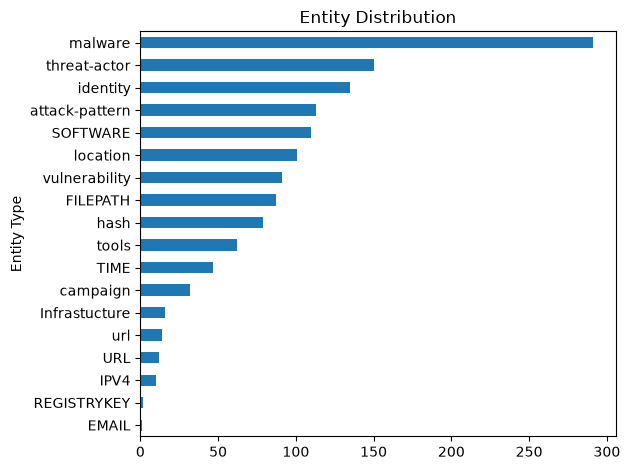

In [ ]:
# Plotting the distribution of entity types as a bar chart
plt.figure(figsize=(10,5))
entity_df.sort_values("Count").plot(x="Entity Type", y="Count", kind="barh", legend=False)
plt.title("Entity Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# Counting the frequency of each relation type in the training dataset
relation_counter = Counter()

for sample in dataset["train"]:
    for relation in sample["relations"]:
        relation_counter[relation["type"]] += 1

relation_counter

Counter({'uses': 141,
         'duplicate-of': 121,
         'indicates': 109,
         'targets': 105,
         'related-to': 70,
         'located-at': 50,
         'has': 46,
         'exploits': 24,
         'attributed-to': 17,
         'downloads': 12,
         'authored-by': 11,
         'variant-of': 10,
         'communicates-with': 9,
         'delivers': 8,
         'beacons-to': 7,
         'consists-of': 7,
         'hosts': 5,
         'impersonates': 4,
         'exfiltrates-to': 3,
         'drops': 2,
         'controls': 1})

In [ ]:
# Convert relation counts into a DataFrame and sort them by their occurence
relation_df = pd.DataFrame(relation_counter.items(), columns=["Relation", "Count"])
relation_df.sort_values("Count", ascending=False)

,Relation,Count
1,uses,141
3,duplicate-of,121
13,indicates,109
0,targets,105
4,related-to,70
7,located-at,50
14,has,46
9,exploits,24
8,attributed-to,17
11,downloads,12


<Figure size 800x400 with 0 Axes>

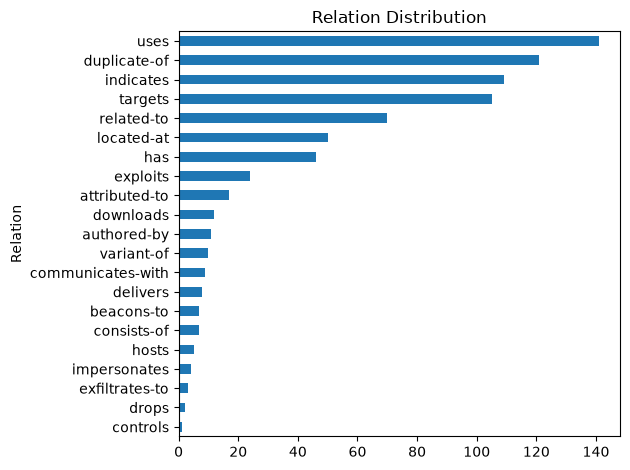

In [ ]:
# Plotting the distribution of relation types as a bar chart
plt.figure(figsize=(8,4))

relation_df.sort_values("Count").plot( x="Relation", y="Count", kind="barh",legend=False)
plt.title("Relation Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# Displaying the first five training samples with their entities and relations
for i in range(5):
    sample = dataset["train"][i]
    print("="*100)
    print("Sentence:")
    print(sample["text"])
    print("\nEntities:")
    for entity in sample["entities"]:
        print(entity)

    print("\nRelations:")
    for relation in sample["relations"]:
        print(relation)

Sentence:
A cybersquatting domain save-russia[.]today is launching DoS attacks on Ukrainian news sites.

Entities:
{'end_offset': 16, 'id': 44656, 'label': 'attack-pattern', 'start_offset': 2}
{'end_offset': 43, 'id': 44657, 'label': 'url', 'start_offset': 24}
{'end_offset': 68, 'id': 44658, 'label': 'attack-pattern', 'start_offset': 57}
{'end_offset': 92, 'id': 44659, 'label': 'identity', 'start_offset': 72}

Relations:
{'from_id': 44658, 'id': 9, 'to_id': 44659, 'type': 'targets'}
{'from_id': 44656, 'id': 114, 'to_id': 44657, 'type': 'uses'}
{'from_id': 44658, 'id': 115, 'to_id': 44657, 'type': 'uses'}
Sentence:
Like the Android Maikspy, it first sends a notification to its C&C server to register the device.

Entities:
{'end_offset': 17, 'id': 48530, 'label': 'SOFTWARE', 'start_offset': 9}
{'end_offset': 24, 'id': 48531, 'label': 'malware', 'start_offset': 17}
{'end_offset': 73, 'id': 48532, 'label': 'Infrastucture', 'start_offset': 63}

Relations:
{'from_id': 48531, 'id': 445, 'to_i

In [ ]:
# Displaying the entities and their labels for the first three training samples

for i in range(3):

    sample = dataset["train"][i]

    print("="*100)
    print(sample["text"])

    print("\nEntities:")

    for entity in sample["entities"]:

        entity_text = sample["text"][
            entity["start_offset"]:entity["end_offset"]
        ]

        print(f"{entity_text} --> {entity['label']}")

A cybersquatting domain save-russia[.]today is launching DoS attacks on Ukrainian news sites.

Entities:
cybersquatting --> attack-pattern
save-russia[.]today --> url
DoS attacks --> attack-pattern
Ukrainian news sites --> identity
Like the Android Maikspy, it first sends a notification to its C&C server to register the device.

Entities:
Android  --> SOFTWARE
Maikspy --> malware
C&C server --> Infrastucture
While analyzing the technical details of this malware, which includes two new espionage backdoors, we noticed striking similarities to other malware attributed to the threat actor known as APT37, also known as Reaper or Group 123.

Entities:
 APT37 --> threat-actor
Reaper  --> threat-actor
Group 123 --> threat-actor
